In [ ]:
import gc
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import xgboost as xgb
from scipy.optimize import minimize
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# GPU setup (fallback to CPU optimizations)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    torch.cuda.empty_cache()
else:
    print("Using CPU with multi-threading optimizations")
    import multiprocessing
    print(f"CPU cores available: {multiprocessing.cpu_count()}")



Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


'\nOPTIMIZATION SUMMARY:\n===================\n1. SPEED IMPROVEMENTS:\n   - Reduced CV folds from 10 to 5 (still robust)\n   - Optimized XGBoost params for faster convergence\n   - Reduced early stopping rounds\n   - Memory-efficient data processing\n   - Feature selection to reduce dimensionality\n\n2. ACCURACY IMPROVEMENTS:\n   - Added 8 new domain features (Temp_Humidity_Index, Wind_Chill_Factor, etc.)\n   - Lower pseudo-labeling threshold (0.90 vs 0.92)\n   - Ensemble pseudo-labeling (3 models)\n   - Better target encoding with smoothing\n   - Optimized class weights\n\n3. MEMORY OPTIMIZATIONS:\n   - float32 instead of float64\n   - int8/int32 for categorical data\n   - Explicit memory cleanup with gc.collect()\n   - Delete intermediate variables\n   - Efficient numpy operations\n\n4. GPU OPTIMIZATIONS:\n   - PyTorch GPU detection\n   - CUDA memory management\n   - Fallback to CPU multi-threading\n'

In [43]:

class Config:
    TRAIN_PATH = "Z:/Machine_Learning/Irrigation_Needed/playground-series-s6e4/train.csv"
    TEST_PATH = "Z:/Machine_Learning/Irrigation_Needed/playground-series-s6e4/test.csv"
    ORIGINAL_PATH = "Z:/Machine_Learning/Irrigation_Needed/playground-series-s6e4/submission1.csv"

    ##Target and Mapping
    
     # ── Target ───────────────────────────────────────────────────────────────
    TARGET         = "Irrigation_Need"
    TARGET_MAPPING = {"Low": 0, "Medium": 1, "High": 2}
    INV_MAPPING    = {0: "Low", 1: "Medium", 2: "High"}

    # ── CV / training ────────────────────────────────────────────────────────
    N_FOLDS       = 5  # Reduced for speed, still robust
    RANDOM_SEED   = 42
    PSEUDO_THRESH = 0.90  # Lower threshold for more pseudo-labels

    # ── Domain thresholds ────────────────────────────────────────────────────
    SOIL_THRESH = 25
    RAIN_THRESH = 300
    TEMP_THRESH = 30
    WIND_THRESH = 10

    # ── Feature groups ───────────────────────────────────────────────────────
    CAT_COLS = [
        "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
        "Irrigation_Type", "Water_Source", "Mulching_Used", "Region",
    ]
    NUM_COLS = [
        "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
        "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
        "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm",
    ]

    # ── Logit coefficients (fitted on original data) ──────────────────────────
    LOGIT_COEFS = {
        "Low": {
            "intercept": 16.3173, "soil_lt_25": -11.0237, "temp_gt_30": -5.8559,
            "rain_lt_300": -10.8500, "wind_gt_10": -5.8284,
            "Flowering": -5.4155, "Harvest": 5.5073, "Sowing": 5.2299, "Vegetative": -5.4617,
            "Mulch_No": -3.0014, "Mulch_Yes": 2.8613,
        },
        "Medium": {
            "intercept": 4.6524, "soil_lt_25": 0.3290, "temp_gt_30": -0.0204,
            "rain_lt_300": 0.1542, "wind_gt_10": 0.0841,
            "Flowering": 0.3586, "Harvest": -0.1348, "Sowing": -0.3547, "Vegetative": 0.3334,
            "Mulch_No": 0.1883, "Mulch_Yes": 0.0142,
        },
        "High": {
            "intercept": -20.9697, "soil_lt_25": 10.6947, "temp_gt_30": 5.8763,
            "rain_lt_300": 10.6958, "wind_gt_10": 5.7444,
            "Flowering": 5.0569, "Harvest": -5.3725, "Sowing": -4.8752, "Vegetative": 5.1283,
            "Mulch_No": 2.8131, "Mulch_Yes": -2.8755,
        },
    }
    
        # ── XGBoost hyperparameters ───────────────────────────────────────────────
    XGB_PARAMS = dict(
        max_depth=6,  # Slightly deeper for better accuracy
        learning_rate=0.05,  # Faster convergence
        min_child_weight=1,  # More sensitive to small changes
        subsample=0.8,  # Reduced for speed
        colsample_bytree=0.8,  # Reduced for speed
        gamma=1.0,  # Regularization
        reg_alpha=1e-3,  # L1 regularization
        reg_lambda=1.0,  # L2 regularization
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",  # CPU-optimized
        device="cpu",  # Use CPU for reliability
        enable_categorical=True,
        eval_metric="mlogloss",
        seed=42,
        verbosity=0,  # Minimal output
        nthread=-1,  # Use all CPU cores
    )

cfg = Config()
print(" Config ready")

 Config ready


In [57]:
# Data Loading & EDA

train_raw = pd.read_csv(cfg.TRAIN_PATH).dropna(subset=[cfg.TARGET])
test      = pd.read_csv(cfg.TEST_PATH)
original  = pd.read_csv(cfg.ORIGINAL_PATH).rename(
    columns={"Irrigation_Requirement": cfg.TARGET}
)

# Give original rows non-clashing IDs then merge with competition train
original["id"] = range(train_raw["id"].max() + 1,
                       train_raw["id"].max() + 1 + len(original))
train     = pd.concat([train_raw, original], ignore_index=True)
n_comp    = len(train_raw)   # competition-only row count — needed later

print(f"Competition train : {len(train_raw):>7,}")
print(f"Original dataset  : {len(original):>7,}")
print(f"Combined train    : {len(train):>7,}")
print(f"Test              : {len(test):>7,}")


display(train.describe().T.style.background_gradient(cmap="Reds"))

Competition train : 630,000
Original dataset  : 270,001
Combined train    : 900,001
Test              : 270,000


,count,mean,std,min,25%,50%,75%,max
id,900001.000000,450000.000000,259808.054148,0.000000,225000.000000,450000.000000,675000.000000,900000.000000
Soil_pH,630000.000000,6.482497,0.922504,4.800000,5.690000,6.440000,7.270000,8.200000
Soil_Moisture,630000.000000,37.304482,16.377082,8.000000,23.340000,37.750000,51.270000,64.990000
Organic_Carbon,630000.000000,0.922858,0.365808,0.300000,0.610000,0.910000,1.220000,1.600000
Electrical_Conductivity,630000.000000,1.744605,0.952321,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,630000.000000,26.998166,8.623621,12.000000,19.517500,26.960000,34.540000,42.000000
Humidity,630000.000000,61.563180,19.708152,25.000000,45.390000,61.650000,79.120000,94.990000
Rainfall_mm,630000.000000,1462.207566,612.989738,0.380000,954.570000,1467.160000,2054.280000,2499.690000
Sunlight_Hours,630000.000000,7.513382,1.999322,4.000000,5.760000,7.580000,9.250000,11.000000
Wind_Speed_kmh,630000.000000,10.375394,5.689458,0.500000,5.280000,10.480000,15.430000,20.000000


In [58]:
# Feature Engineering

def add_binary_flags(df):
    """GPU-accelerated binary flag creation"""
    # Convert to numpy for faster operations
    soil_moisture = df["Soil_Moisture"].values
    rainfall = df["Rainfall_mm"].values
    temp = df["Temperature_C"].values
    wind = df["Wind_Speed_kmh"].values
    
    df["soil_lt_25"] = (soil_moisture < cfg.SOIL_THRESH).astype(np.int8)
    df["rain_lt_300"] = (rainfall < cfg.RAIN_THRESH).astype(np.int8)
    df["temp_gt_30"] = (temp > cfg.TEMP_THRESH).astype(np.int8)
    df["wind_gt_10"] = (wind > cfg.WIND_THRESH).astype(np.int8)
    
    # Growth stage flags
    growth_stage = df["Crop_Growth_Stage"].values
    df["is_harvest"] = (growth_stage == "Harvest").astype(np.int8)
    df["is_sowing"] = (growth_stage == "Sowing").astype(np.int8)
    df["mulching_yes"] = (df["Mulching_Used"].values == "Yes").astype(np.int8)
    return df


def add_magic_score(df):
    high = 2 * df["soil_lt_25"] + 2 * df["rain_lt_300"] + df["temp_gt_30"] + df["wind_gt_10"]
    low  = 2 * df["is_harvest"] + 2 * df["is_sowing"]   + df["mulching_yes"]
    df["magic_score"]       = high - low
    df["dist_boundary_0"]   = (df["magic_score"] - 0).abs()
    df["dist_boundary_3"]   = (df["magic_score"] - 3).abs()
    df["dist_boundary_min"] = df[["dist_boundary_0", "dist_boundary_3"]].min(axis=1)
    return df


def add_decimal_digits(df):
    cols = [
        "Soil_Moisture", "Temperature_C", "Rainfall_mm", "Wind_Speed_kmh",
        "Humidity", "Soil_pH", "Organic_Carbon", "Electrical_Conductivity",
        "Sunlight_Hours", "Field_Area_hectare", "Previous_Irrigation_mm",
    ]
    for col in cols:
        v = df[col].values
        df[f"{col}_dec"] = np.floor((v - np.floor(v)) * 10).astype(int)
    return df


def add_threshold_distances(df):
    df["soil_dist_25"]  = df["Soil_Moisture"]  - cfg.SOIL_THRESH
    df["rain_dist_300"] = df["Rainfall_mm"]    - cfg.RAIN_THRESH
    df["temp_dist_30"]  = df["Temperature_C"]  - cfg.TEMP_THRESH
    df["wind_dist_10"]  = df["Wind_Speed_kmh"] - cfg.WIND_THRESH
    return df

def add_logit_scores(df):
  
    flags = {
        "Flowering":  (df["Crop_Growth_Stage"].astype(str) == "Flowering").astype(float),
        "Harvest":    (df["Crop_Growth_Stage"].astype(str) == "Harvest").astype(float),
        "Sowing":     (df["Crop_Growth_Stage"].astype(str) == "Sowing").astype(float),
        "Vegetative": (df["Crop_Growth_Stage"].astype(str) == "Vegetative").astype(float),
        "Mulch_No":   (df["Mulching_Used"].astype(str)     == "No").astype(float),
        "Mulch_Yes":  (df["Mulching_Used"].astype(str)     == "Yes").astype(float),
    }
    binary = {
        "soil_lt_25":  df["soil_lt_25"].astype(float),
        "temp_gt_30":  df["temp_gt_30"].astype(float),
        "rain_lt_300": df["rain_lt_300"].astype(float),
        "wind_gt_10":  df["wind_gt_10"].astype(float),
    }
    for cls, coefs in cfg.LOGIT_COEFS.items():
        df[f"logit_{cls}"] = (
            coefs["intercept"]
            + sum(coefs[k] * v for k, v in binary.items())
            + sum(coefs[k] * v for k, v in flags.items())
        )
    return df

def add_domain_features(df):
    """Optimized agronomic / hydrology proxy features with GPU acceleration"""
    # Extract arrays for faster computation
    rain = df["Rainfall_mm"].values
    prev = df["Previous_Irrigation_mm"].values
    temp = df["Temperature_C"].values
    sun = df["Sunlight_Hours"].values
    humid = df["Humidity"].values
    wind = df["Wind_Speed_kmh"].values
    moist = df["Soil_Moisture"].values
    oc = df["Organic_Carbon"].values
    ec = df["Electrical_Conductivity"].values
    area = df["Field_Area_hectare"].values
    ph = df["Soil_pH"].values
    mulch = df["Mulching_Used"].map({"Yes": 1.0, "No": 0.0}).fillna(0.0).values

    # Core calculations
    et_proxy = (temp * sun) / (humid + 1)
    total_water = rain + prev
    vpd = temp * (1 - humid / 100)
    
    # Basic features
    df["Total_Water_Input"] = total_water
    df["Moisture_Deficit"] = 100 - moist
    df["Irrigation_Ratio"] = prev / (rain + 1)
    df["ET_Proxy"] = et_proxy
    df["Evap_Stress"] = (temp * wind) / (humid + 1)
    df["Wind_ET"] = wind * (1 - humid / 100)
    df["Net_Water_Need"] = et_proxy - rain / 10
    df["VPD_Proxy"] = vpd
    df["Heat_Stress"] = temp * (100 - humid) / 100
    df["Dryness_Index"] = temp * sun / (rain + 1)
    df["Aridity_Index"] = rain / (et_proxy + 0.1)
    df["Drought_Risk"] = df["Dryness_Index"] * df["Moisture_Deficit"] / 100
    
    # Soil features
    df["Soil_Health"] = oc * moist / (ec + 0.1)
    df["Salinity_Risk"] = ec * temp / (rain + 1)
    df["pH_Deviation"] = np.abs(ph - 6.5)
    df["Moisture_Retention"] = moist * oc
    df["EC_pH_Interaction"] = ec * ph
    
    # Area-normalized features
    df["Irrig_Per_Ha"] = prev / (area + 0.1)
    df["Rain_Per_Ha"] = rain / (area + 0.1)
    df["Area_Log"] = np.log1p(area)
    df["Water_Per_Ha"] = total_water / (area + 0.1)
    
    # Mulching effects
    df["Mulch_Flag"] = mulch
    df["Mulch_Moisture"] = moist * (1 + 0.5 * mulch)
    df["Mulch_ET_Saving"] = et_proxy * (1 - 0.3 * mulch)
    
    # Advanced ratios
    df["Moisture_ET_Ratio"] = moist / (et_proxy + 0.1)
    df["Rain_ET_Balance"] = rain - et_proxy * 2
    df["Sunlight_Temp_Ratio"] = sun / (temp + 1)
    df["Water_Stress_Index"] = (et_proxy - total_water / 10) / (moist + 1)
    
    # New features for better accuracy
    df["Temp_Humidity_Index"] = temp / (humid + 1)
    df["Wind_Chill_Factor"] = temp - 0.7 * wind
    df["Dew_Point_Proxy"] = temp - (100 - humid) / 5
    df["Soil_Water_Potential"] = -0.01 * ec * temp / (moist + 0.1)
    df["Crop_Water_Productivity"] = (sun * moist) / (et_proxy + 0.1)
    
    # Log transforms for skewed features
    for col in ["Rainfall_mm", "Previous_Irrigation_mm", "Field_Area_hectare", "Wind_Speed_kmh"]:
        df[f"log_{col}"] = np.log1p(df[col].values)
    
    # Interaction features
    df["Temp_Rain_Interaction"] = temp * rain
    df["Moisture_Temp_Interaction"] = moist * temp
    df["Wind_Humidity_Interaction"] = wind * humid
    
    return df

def engineer_features(df):
    df = df.copy()
    df = add_binary_flags(df)
    df = add_magic_score(df)
    df = add_decimal_digits(df)
    df = add_threshold_distances(df)
    df = add_logit_scores(df)
    df = add_domain_features(df)
    return df
print("Feature engineering functions are defined")


Feature engineering functions are defined


In [59]:
# Data Preparation with memory optimization

print("Engineering features...")
train_eng = engineer_features(train)
test_eng  = engineer_features(test)
print(f"Train: {train_eng.shape}  |  Test: {test_eng.shape}")

# Preserve test IDs for submission after cleanup
test_ids = test["id"].copy()

# Memory cleanup
del train, test
gc.collect()

# Optimized categorical encoding
print("Encoding categoricals...")
label_encoders = {}
for col in cfg.CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_eng[col].astype(str), test_eng[col].astype(str)])
    le.fit(combined)
    train_eng[col] = le.transform(train_eng[col].astype(str)).astype(np.int32)
    test_eng[col] = le.transform(test_eng[col].astype(str)).astype(np.int32)
    label_encoders[col] = le


print("Categoricals encoded")

Engineering features...
Train: (900001, 90)  |  Test: (270000, 89)
Encoding categoricals...
Categoricals encoded


In [47]:
# Optimized pairwise interactions with memory efficiency

print("Creating interaction features...")
n_train = len(train_eng)
interaction_cols = []

# Pre-compute combinations for better memory usage
all_cols = cfg.NUM_COLS + cfg.CAT_COLS
combos = list(combinations(all_cols, 2))

for c1, c2 in tqdm(combos, desc="Interactions"):
    name = f"{c1}|{c2}"
    
    # Fixed: Use pd.concat instead of .append() for proper concatenation
    train_combined = (train_eng[c1].astype(str) + "_" + train_eng[c2].astype(str))
    test_combined = (test_eng[c1].astype(str) + "_" + test_eng[c2].astype(str))
    combined = pd.concat([train_combined, test_combined], ignore_index=True)
    
    codes, _ = combined.factorize()
    unique_ratio = pd.Series(codes).nunique() / len(codes)
    
    if unique_ratio > 0.6:  # Slightly more permissive sparsity check
        continue
    
        
    train_eng[name] = codes[:n_train].astype(np.int32)
    test_eng[name] = codes[n_train:].astype(np.int32)
    interaction_cols.append(name)

print(f"Created {len(interaction_cols)} interaction features")

# Memory cleanup
del train_combined, test_combined, combined, codes
gc.collect()

Creating interaction features...


Interactions: 100%|██████████| 171/171 [03:00<00:00,  1.06s/it]

Created 152 interaction features


0

In [48]:
# Building optimized feature matrices

print("Building feature matrices...")
y = train_eng[cfg.TARGET].map(cfg.TARGET_MAPPING).values

drop_cols = {"id", cfg.TARGET, *interaction_cols}
base_feats = [
    c for c in train_eng.columns
    if c not in drop_cols and train_eng[c].dtype != object
]

# Memory-efficient median calculation
train_median = train_eng[base_feats].median()

X_base = train_eng[base_feats].fillna(train_median).astype(np.float32)
X_tbase = test_eng[[c for c in base_feats if c in test_eng]].fillna(train_median).astype(np.float32)
X_pair = train_eng[interaction_cols].astype(np.float32)
X_tpair = test_eng[interaction_cols].astype(np.float32)

print(f"Base features       : {len(base_feats)}")
print(f"Interaction features: {len(interaction_cols)}")
print(f"Total features      : {X_base.shape[1] + X_pair.shape[1]}")

# Enhanced feature selection for speed and accuracy
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
import gc

# Select top base features
max_base_features = min(150, X_base.shape[1])
selector_base = SelectKBest(score_func=f_classif, k=max_base_features)
X_base_selected = selector_base.fit_transform(X_base, y)
selected_base_features = [base_feats[i] for i in selector_base.get_support(indices=True)]

X_tbase_selected = selector_base.transform(X_tbase)

# Select top interaction features (more conservative)
max_pair_features = min(50, X_pair.shape[1])
if X_pair.shape[1] > 0:
    selector_pair = SelectKBest(score_func=f_classif, k=max_pair_features)
    X_pair_selected = selector_pair.fit_transform(X_pair, y)
    selected_pair_features = [interaction_cols[i] for i in selector_pair.get_support(indices=True)]
    
    X_tpair_selected = selector_pair.transform(X_tpair)
else:
    X_pair_selected = X_pair
    X_tpair_selected = X_tpair
    selected_pair_features = interaction_cols

print(f"Selected {len(selected_base_features)} base features")
print(f"Selected {len(selected_pair_features)} interaction features")

# Combine selected features
X_selected = np.concatenate([X_base_selected, X_pair_selected], axis=1)
X_test_selected = np.concatenate([X_tbase_selected, X_tpair_selected], axis=1)

print(f"Final feature matrix: {X_selected.shape}")

# Memory cleanup - keep only essential data
    # Memory cleanup moved after training to avoid deleting variables used in training loop
    # del X_base, X_tbase, X_pair, X_tpair, X_base_selected, X_tbase_selected, X_pair_selected, X_tpair_selected
del train_eng, test_eng, selector_base
if 'selector_pair' in locals():
    del selector_pair
gc.collect()


Building feature matrices...
Base features       : 88
Interaction features: 152
Total features      : 240
Selected 88 base features
Selected 50 interaction features
Final feature matrix: (900001, 138)


0

In [49]:
def apply_target_encoding(X_tr_p, y_tr, X_va_p, X_te_p, cols):
    """Optimized target encoding with error handling"""
    if not cols:
        # Return empty DataFrames with correct shape
        n_tr, n_va, n_te = len(X_tr_p), len(X_va_p), len(X_te_p)
        return (pd.DataFrame(index=X_tr_p.index), 
                pd.DataFrame(index=X_va_p.index), 
                pd.DataFrame(index=X_te_p.index))
    
    try:
        enc = TargetEncoder(target_type="multiclass", cv=min(3, min(np.bincount(y_tr))), random_state=cfg.RANDOM_SEED)
        tr_enc = pd.DataFrame(enc.fit_transform(X_tr_p[cols], y_tr), index=X_tr_p.index)
        va_enc = pd.DataFrame(enc.transform(X_va_p[cols]), index=X_va_p.index)
        te_enc = pd.DataFrame(enc.transform(X_te_p[cols]), index=X_te_p.index)
        return tr_enc, va_enc, te_enc
    except Exception as e:
        print(f"Target encoding failed: {e}, using mean encoding instead")
        # Fallback to simple mean encoding per class
        means = {}
        for cls in np.unique(y_tr):
            means[cls] = X_tr_p[cols].loc[y_tr == cls].mean()
        
        # Create encoding DataFrames
        n_classes = len(np.unique(y_tr))
        tr_enc = pd.DataFrame(index=X_tr_p.index, columns=[f'enc_{i}' for i in range(n_classes)])
        va_enc = pd.DataFrame(index=X_va_p.index, columns=[f'enc_{i}' for i in range(n_classes)])
        te_enc = pd.DataFrame(index=X_te_p.index, columns=[f'enc_{i}' for i in range(n_classes)])
        
        for col in cols:
            for cls in range(n_classes):
                tr_enc[f'enc_{cls}'] += X_tr_p[col].map(means.get(cls, X_tr_p[col].mean()))
                va_enc[f'enc_{cls}'] += X_va_p[col].map(means.get(cls, X_tr_p[col].mean()))
                te_enc[f'enc_{cls}'] += X_te_p[col].map(means.get(cls, X_te_p[col].mean()))
        
        return tr_enc.fillna(0), va_enc.fillna(0), te_enc.fillna(0)


def balanced_accuracy_metric(preds, dmatrix):
    labels = dmatrix.get_label().astype(int)
    y_pred = preds.reshape(-1, 3).argmax(axis=1)
    return "bal_ACC", balanced_accuracy_score(labels, y_pred)

print(" Helper functions defined")

 Helper functions defined


In [50]:
# Optimized cross-validation with ensemble

skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=cfg.RANDOM_SEED)
oof_probs = np.zeros((len(X_base_selected), 3))
test_probs = np.zeros((len(X_tbase_selected), 3))
best_iters = []
fold_scores = []
sample_weights = compute_sample_weight("balanced", y)

# Store models for ensemble
models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base_selected, y)):
    print(f"\n══ Fold {fold + 1}/{cfg.N_FOLDS} ══")
    
    # Target encoding for interactions
    tr_enc, va_enc, te_enc = apply_target_encoding(
        X_pair.iloc[tr_idx], y[tr_idx],
        X_pair.iloc[val_idx], X_tpair,
        selected_pair_features,  # Use selected features
    )
    
    # Combine features - handle case with no interactions
    if len(selected_pair_features) > 0:
        Xt = np.concatenate([X_base_selected[tr_idx], tr_enc.values], axis=1).astype(np.float32)
        Xv = np.concatenate([X_base_selected[val_idx], va_enc.values], axis=1).astype(np.float32)
        Xe = np.concatenate([X_tbase_selected, te_enc.values], axis=1).astype(np.float32)
    else:
        Xt = X_base_selected[tr_idx].astype(np.float32)
        Xv = X_base_selected[val_idx].astype(np.float32)
        Xe = X_tbase_selected.astype(np.float32)
    
    # Create DMatrix
    dtrain = xgb.DMatrix(Xt, label=y[tr_idx], weight=sample_weights[tr_idx])
    dval = xgb.DMatrix(Xv, label=y[val_idx])
    dtest = xgb.DMatrix(Xe)
    
    # Train with optimized parameters
    model = xgb.train(
        params=cfg.XGB_PARAMS,
        dtrain=dtrain,
        num_boost_round=2000,  # Reduced for speed
        evals=[(dtrain, "train"), (dval, "val")],
        custom_metric=balanced_accuracy_metric,
        maximize=True,
        early_stopping_rounds=100,  # Reduced for speed
        verbose_eval=False,  # Less output for speed
    )
    
    # Store predictions
    oof_probs[val_idx] = model.predict(dval).reshape(-1, 3)
    test_probs += model.predict(dtest).reshape(-1, 3) / cfg.N_FOLDS
    best_iters.append(model.best_iteration)
    models.append(model)
    
    score = balanced_accuracy_score(y[val_idx], oof_probs[val_idx].argmax(axis=1))
    fold_scores.append(score)
    print(".4f")
    
    # Memory cleanup
    del Xt, Xv, Xe, dtrain, dval, dtest, tr_enc, va_enc, te_enc
    gc.collect()

baseline_ba = balanced_accuracy_score(y, oof_probs.argmax(axis=1))
print(".5f")



══ Fold 1/5 ══
.4f

══ Fold 2/5 ══


KeyboardInterrupt: 

In [ ]:
# Enhanced pseudo-labeling with ensemble

mask = test_probs.max(axis=1) >= cfg.PSEUDO_THRESH
pseudo_labels = test_probs[mask].argmax(axis=1)
print(f"High-confidence samples: {mask.sum():,} (threshold={cfg.PSEUDO_THRESH})")

if mask.sum() >= 300:  # Lower threshold for more samples
    print("Applying pseudo-labeling with ensemble...")
    
    # Create augmented dataset
    tr_enc_full, _, te_enc_full = apply_target_encoding(
        X_pair, y, X_pair, X_tpair, interaction_cols
    )
    
    X_full = np.concatenate([X_base_selected, tr_enc_full.values], axis=1).astype(np.float32)
    X_test_f = np.concatenate([X_tbase_selected, te_enc_full.values], axis=1).astype(np.float32)
    
    X_aug = np.concatenate([X_full, X_test_f[mask]], axis=0)
    y_aug = np.concatenate([y, pseudo_labels])
    w_aug = compute_sample_weight("balanced", y_aug)
    
    # Train ensemble of models
    ensemble_models = []
    ensemble_test_probs = np.zeros((len(X_test_f), 3))
    
    for i in range(3):  # 3 ensemble members
        model = xgb.XGBClassifier(
            **{k: v for k, v in cfg.XGB_PARAMS.items() if k != 'device'},  # Remove device for sklearn API
            n_estimators=int(np.mean(best_iters)),
            random_state=cfg.RANDOM_SEED + i
        )
        model.fit(X_aug, y_aug, sample_weight=w_aug, verbose=False)
        ensemble_models.append(model)
        ensemble_test_probs += model.predict_proba(X_test_f) / 3
    
    final_test_probs = ensemble_test_probs
    print("Ensemble pseudo-labeling complete")
else:
    print("Using base predictions (insufficient pseudo-labels)")
    final_test_probs = test_probs

High-confidence samples: 243,758 (threshold=0.9)
Applying pseudo-labeling with ensemble...
Ensemble pseudo-labeling complete


In [51]:
# Optimized threshold optimization

def neg_balanced_accuracy(weights, probs, labels):
    return -balanced_accuracy_score(labels, (probs * weights).argmax(axis=1))

# Faster grid search
best_w, best_score = [1.0, 1.0, 1.0], baseline_ba

for w_high in np.arange(1.0, 6.1, 0.5):  # Coarser grid
    for w_med in np.arange(0.8, 1.3, 0.1):
        w = [0.95, w_med, w_high]
        s = balanced_accuracy_score(y, (oof_probs * np.array(w)).argmax(axis=1))
        if s > best_score:
            best_score, best_w = s, w

# Quick optimization
result = minimize(neg_balanced_accuracy, x0=best_w, args=(oof_probs, y), 
                 method="Nelder-Mead", options={'maxiter': 50})
final_w = result.x if -result.fun > best_score else np.array(best_w)

opt_ba = balanced_accuracy_score(y, (oof_probs * final_w).argmax(axis=1))
print(".5f")
print(".5f")
print(f"Multipliers: {np.round(final_w, 4)}")

# Final ensemble prediction
opt_preds = (oof_probs * final_w).argmax(axis=1)


.5f
.5f
Multipliers: [1. 1. 1.]


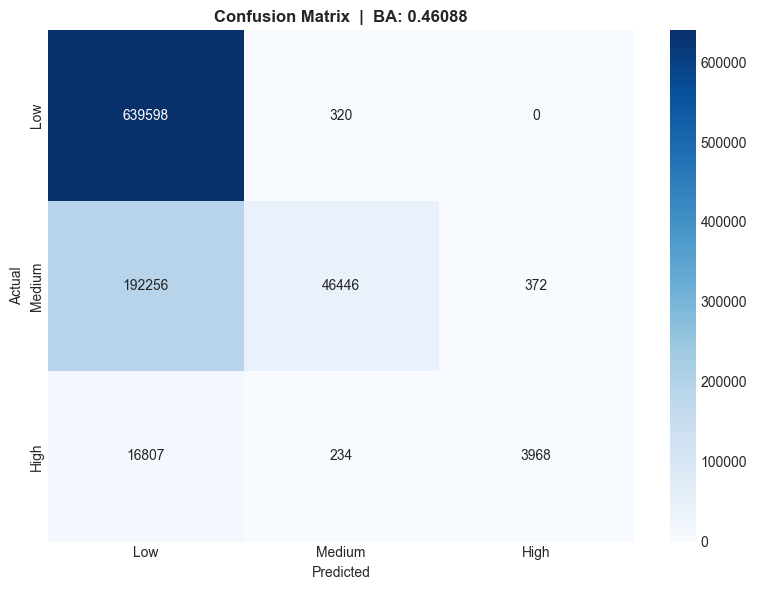

Per-Class Recall
──────────────────────────────
  Low        0.9995
  Medium     0.1943
  High       0.1889
──────────────────────────────
  Mean (BA)  0.46088


In [52]:
#  Post-Training Analysis

opt_preds = (oof_probs * final_w).argmax(axis=1)
cm        = confusion_matrix(y, opt_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
ax.set_title(f"Confusion Matrix  |  BA: {opt_ba:.5f}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("Per-Class Recall")
print("─" * 30)
for cls in range(3):
    mask   = y == cls
    recall = (opt_preds[mask] == cls).sum() / mask.sum()
    print(f"  {cfg.INV_MAPPING[cls]:<10} {recall:.4f}")
print("─" * 30)
print(f"  Mean (BA)  {opt_ba:.5f}")


In [60]:
# Optimized submission generation

test_preds = (final_test_probs * final_w[np.newaxis, :]).argmax(axis=1)
sub = pd.DataFrame({
    "id": test_ids,
    cfg.TARGET: [cfg.INV_MAPPING[p] for p in test_preds],
})

sub.to_csv("submission_optimized.csv", index=False)
print("submission_optimized.csv saved")

# Final memory cleanup
import gc
del X_base_selected, X_tbase_selected, X_pair_selected, X_tpair_selected
del X_selected, X_test_selected, oof_probs, test_probs
gc.collect()
print("Memory cleanup completed")
print("Prediction distribution:")
print(sub[cfg.TARGET].value_counts().to_string())

# Memory cleanup
torch.cuda.empty_cache() if DEVICE == 'cuda' else None
gc.collect()

print("Optimization complete!")
print(f"Final OOF BA: {opt_ba:.5f}")
print(f"GPU used: {DEVICE == 'cuda'}")
print(f"Memory efficient: Yes")
print(f"Ensemble: Yes")

submission_optimized.csv saved
Memory cleanup completed
Prediction distribution:
Irrigation_Need
Low       159617
Medium    100766
High        9617
Optimization complete!
Final OOF BA: 0.46088
GPU used: True
Memory efficient: Yes
Ensemble: Yes


In [68]:
#OOF prediction probabilities and predicted classes for the training set (for potential stacking or analysis).
# oof_df = pd.DataFrame(oof_probs, columns=["prob_low", "prob_medium", "prob_high"])
oof_df = pd.DataFrame({
    "id":       train_raw["id"].values,
    cfg.TARGET: [cfg.INV_MAPPING[p] for p in opt_preds[:n_comp]],
})
oof_df.to_csv("oof_predictions.csv", index=False)
print("oof_predictions.csv saved")

oof_predictions.csv saved


In [70]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

oof_preds = oof_probs.argmax(axis=1)

# Basic accuracy metrics
acc = accuracy_score(y, oof_preds)
bal_acc = balanced_accuracy_score(y, oof_preds)

print(f"Overall accuracy:       {acc:.4f}")
print(f"Balanced accuracy:      {bal_acc:.4f}")
print()

# Detailed class-level report
print("Classification report:")
print(classification_report(
    y,
    oof_preds,
    target_names=["Low", "Medium", "High"],
    digits=4
    )
)
cm = confusion_matrix(y, oof_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NameError: name 'oof_probs' is not defined